1. Given Transform X(s):


s/(-k**2 + s**2)

Poles of the function: [-k, k]

Residue at s = k:


exp(k*t)/2

Residue at s = -k:


exp(-k*t)/2


2. Computed Inverse Transform x(t) (sum of residues):


exp(k*t)/2 + exp(-k*t)/2

Simplified result:


cosh(k*t)

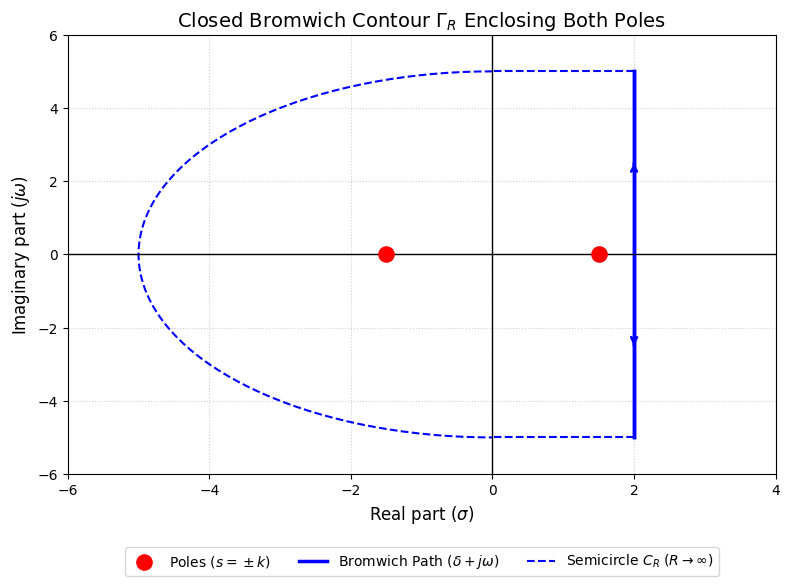

In [5]:
# Notebook: Inverse Laplace Transform via Complex Integration (Bromwich Contour)
# Example: X(s) = s / (s^2 - k^2) -> x(t) = cosh(k*t)

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# --- 1. SYMPY: Symbolic calculation & Residues ---
s = sp.Symbol('s')
t = sp.Symbol('t', real=True, positive=True)
k = sp.Symbol('k', positive=True, real=True)

# Define the transform X(s)
X_s = s / (s**2 - k**2)

print("1. Given Transform X(s):")
display(X_s)

# Function inside the Bromwich integral: X(s) * exp(s*t)
integrand = X_s * sp.exp(s * t)

# Find poles: s = k and s = -k
poles = sp.solve(s**2 - k**2, s)
print("Poles of the function:", poles)

# Compute residues at s = k and s = -k via SymPy
res_k = sp.limit(integrand * (s - k), s, k)
res_minus_k = sp.limit(integrand * (s + k), s, -k)

print("\nResidue at s = k:")
display(res_k)

print("Residue at s = -k:")
display(res_minus_k)

# Total inverse transform by sum of residues (Residue Theorem)
x_t_computed = res_k + res_minus_k
print("\n2. Computed Inverse Transform x(t) (sum of residues):")
display(x_t_computed)

# Simplify to hyperbolic cosine form: cosh(k*t)
x_t_simplified = sp.simplify(x_t_computed)
print("Simplified result:")
display(x_t_simplified)


# --- 2. MATPLOTLIB: Visualization of the Bromwich Contour and Poles ---
fig, ax = plt.subplots(figsize=(8, 6))

k_val = 1.5
delta = 2.0  # Abscissa of convergence Re(s) = delta > k
R = 5.0      # Radius of semicircle

# 1. Plot poles at s = k and s = -k (using raw strings 'r""')
pole_re = [k_val, -k_val]
pole_im = [0, 0]
ax.scatter(pole_re, pole_im, color='red', s=120, zorder=5, label=r'Poles ($s = \pm k$)')

# 2. Draw the vertical line (Bromwich path from -R to +R at Re(s) = delta)
ax.plot([delta, delta], [-R, R], color='blue', lw=2.5, label=r'Bromwich Path ($\delta + j\omega$)')

# 3. Semicircular arc on the left (radius R)
y_vals = np.linspace(-R, R, 200)
ax.plot([delta]*len(y_vals), y_vals, color='blue', lw=2.5)

theta_semi = np.linspace(np.pi/2, 3*np.pi/2, 150)
semi_re = R * np.cos(theta_semi)
semi_im = R * np.sin(theta_semi)
ax.plot(semi_re, semi_im, color='blue', ls='--', lw=1.5, label=r'Semicircle $C_R$ ($R \to \infty$)')

# Connecting lines at the poles/infinity
ax.plot([delta, 0], [R, R], color='blue', ls='--', lw=1.5)
ax.plot([delta, 0], [-R, -R], color='blue', ls='--', lw=1.5)

# Arrows indicating direction of integration
ax.annotate('', xy=(delta, R/2), xytext=(delta, R/2 - 0.1), arrowprops=dict(arrowstyle="->", color='blue', lw=2))
ax.annotate('', xy=(delta, -R/2), xytext=(delta, -R/2 + 0.1), arrowprops=dict(arrowstyle="->", color='blue', lw=2))

# Axes styling and annotations (using raw strings)
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlim(-6, 4)
ax.set_ylim(-6, 6)
ax.set_xlabel(r'Real part ($\sigma$)', fontsize=12)
ax.set_ylabel(r'Imaginary part ($j\omega$)', fontsize=12)
ax.set_title(r'Closed Bromwich Contour $\Gamma_R$ Enclosing Both Poles', fontsize=14)
ax.grid(True, linestyle=':', alpha=0.6)

# Legend below the plot
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True)

plt.tight_layout()
plt.show()